In [1]:
import numpy as np
import matplotlib.pyplot as plt
import math
import matplotlib.image as img
import pandas as pd
import os
from pathlib import Path
import read_sim_not_clin_bg as rsnb

### Для просмотра файлов в папке

In [2]:
# folder_path = '/media/alexandra/DATA/IACT02_2020-2021' # второй телескоп
folder_path = '/media/alexandra/DATA/IACT01_2020-2021' # первый телескоп

# Cписок файлов в папке
file_names = os.listdir(folder_path)

# Выводим названия файлов
for file_name in file_names:
    # print(file_name)
    break

### Считываем файлы в таблицу

In [3]:
# folder_path = '/media/alexandra/DATA/IACT02_2020-2021'
folder_path = '/media/alexandra/DATA/IACT01_2020-2021'
df_19 = pd.read_csv('/media/alexandra/DATA/IACT01_231119/231119.01_out_hillas_14_7.0fix.csv') # 19-год (один день)

# Cписок всех CSV-файлов в папке
file_paths = [os.path.join(folder_path, file) for file in os.listdir(folder_path) if file.endswith('.csv')]

# Читаем каждый файл и объединяем их в один DataFrame
dataframes = [pd.read_csv(file) for file in file_paths]
hillas = pd.concat(dataframes, ignore_index=True)
combined_hillas = pd.concat([df_19, hillas], ignore_index=True)

hillas

,por,event_numb,time,unix_time_ns,delta_time,error_deg,tel_az,tel_el,source_az,source_el,...,source_ra,source_dec,source_x,source_y,tracking,good,star,edge,weather_mark,alpha_c
0,1,14,13:37:23:280:261:540,1612791443280261540,0.22,0.03,181.85089,60.151,184.37523,60.168,...,83.63,22.01,1.28,-0.02,1,1,0,0,9.09,0.93
1,1,70,13:37:23:362:354:610,1612791443362354610,0.14,0.03,181.85089,60.151,184.37523,60.168,...,83.63,22.01,1.28,-0.02,1,1,0,0,9.09,0.93
2,1,116,13:37:23:411:776:330,1612791443411776330,0.09,0.03,181.85089,60.151,184.37523,60.168,...,83.63,22.01,1.28,-0.02,1,1,0,0,9.09,0.93
3,1,149,13:37:23:444:607:650,1612791443444607650,0.06,0.03,181.85089,60.151,184.37523,60.168,...,83.63,22.01,1.28,-0.02,1,1,0,0,9.09,0.93
4,1,169,13:37:23:465:362:590,1612791443465362590,0.03,0.03,181.85089,60.151,184.37523,60.168,...,83.63,22.01,1.28,-0.02,1,1,0,0,9.09,0.93
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
3296949,67,887272,16:24:00:251:741:530,1612628640251741530,0.25,0.03,244.91386,45.279,243.62814,46.048,...,83.63,22.01,-0.90,-0.80,0,0,0,0,-1.00,0.49
3296950,67,887273,16:24:00:252:921:020,1612628640252921020,0.25,0.03,244.91386,45.279,243.62814,46.048,...,83.63,22.01,-0.90,-0.80,0,0,0,0,-1.00,0.49
3296951,67,887282,16:24:00:406:925:590,1612628640406925590,0.09,0.03,244.91386,45.279,243.62814,46.048,...,83.63,22.01,-0.90,-0.80,0,0,0,0,-1.00,0.49
3296952,67,887283,16:24:00:421:163:880,1612628640421163880,0.08,0.03,244.91386,45.279,243.62814,46.048,...,83.63,22.01,-0.90,-0.80,0,0,0,0,-1.00,0.49


### Применяем каты

In [4]:
def filter_hillas_data(df):
    # Common filters for both source and anti-source
    common_filters = (
        (df['CR_portion']/np.cos(np.pi/2-np.pi*df['tel_el']/180) > 5) &
        (df['size'] > 120) &
        (df['width'] > 0.024) &
        (df['width'] < 0.068 * np.log10(df['size']) - 0.047) &
        (df['length'] < 0.145 * np.log10(df['size']))
    )
    
    # Source selection (dist1)
    source_df = df[
        common_filters &
        (df['dist1'].between(0.36, 1.44))
    ].copy()
    source_df['source_type'] = 'source'  # Add identifier column
    
    # Anti-source selection (dist2)
    anti_source_df = df[
        common_filters &
        (df['dist2'].between(0.36, 1.44))
    ].copy()
    anti_source_df['source_type'] = 'anti-source'  # Add identifier column
    
    return source_df, anti_source_df

source_events, antisource_events = filter_hillas_data(hillas)
source_events

,por,event_numb,time,unix_time_ns,delta_time,error_deg,tel_az,tel_el,source_az,source_el,...,source_dec,source_x,source_y,tracking,good,star,edge,weather_mark,alpha_c,source_type
1052,1,8265,13:38:25:178:574:640,1612791505178574640,0.18,0.03,182.33163,60.149,184.85313,60.155,...,22.01,1.28,-0.01,1,1,0,0,9.12,0.93,source
1697,1,13435,13:39:06:036:027:050,1612791546036027050,0.04,0.03,182.64775,60.149,185.17154,60.146,...,22.01,1.28,-0.00,1,1,0,0,9.27,0.93,source
1916,1,15163,13:39:19:800:552:970,1612791559800552970,0.20,0.03,182.75627,60.149,185.28023,60.143,...,22.01,1.28,0.00,1,1,0,0,9.27,0.93,source
1928,1,15236,13:39:20:447:435:430,1612791560447435430,0.05,0.03,182.76044,60.149,185.28411,60.142,...,22.01,1.28,0.00,1,1,0,0,9.27,0.93,source
2930,2,39794,13:40:35:333:406:490,1612791635333406490,0.17,0.03,188.13838,59.912,185.86602,60.124,...,22.01,-1.15,-0.25,0,0,0,0,-1.00,0.91,source
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
3295686,66,878763,16:21:50:055:013:780,1612628510055013780,0.06,0.03,244.35383,45.579,243.04193,46.349,...,22.01,-0.92,-0.80,1,1,0,0,9.09,0.50,source
3295812,66,879616,16:22:02:057:862:990,1612628522057862990,0.06,0.03,244.40773,45.551,243.09604,46.321,...,22.01,-0.92,-0.80,1,1,0,0,9.08,0.50,source
3296083,66,881340,16:22:26:047:641:830,1612628546047641830,0.05,0.03,244.51569,45.495,243.20413,46.266,...,22.01,-0.92,-0.80,1,1,0,0,9.08,0.49,source
3296364,67,883301,16:23:04:508:479:340,1612628584508479340,0.01,0.03,244.68243,45.404,243.37718,46.177,...,22.01,-0.92,-0.80,1,1,0,0,9.08,0.49,source


### Накладывем моделирование сверху

In [30]:
# Cчитываем параметры моделирования
file_simulation = '/media/alexandra/DATA/IACT01_2020-2021/Simulation_599/taiga599_hillas_iact01_14_7fix_cb0.csv'
df_simulation_599 = pd.read_csv(file_simulation)

df_simulation_599

,clean_number,event_number,axis_scatter,numb_pix,energy,size,Xc[0],Yc[0],con2,length[0],...,source_y,x_ground,y_ground,tel_tet,tel_fi,source_tet,source_fi,Xmax,num_islands,con_selected_island
0,0,2,5,4,11.64790,191.260,0.043715,0.323091,0.772252,0.259698,...,0.862666,0.964031,215.54100,0.699570,2.41686,0.684378,2.44025,305.978,1,1.0
1,1,2,6,4,11.64790,213.965,0.715517,1.040150,0.680308,0.178572,...,0.862666,42.199400,-3.32466,0.699570,2.41686,0.684378,2.44025,305.978,1,1.0
2,2,2,9,5,11.64790,85.279,1.748660,2.129900,0.506244,0.232608,...,0.862666,110.739000,-323.52600,0.699570,2.41686,0.684378,2.44025,305.978,1,1.0
3,3,11,8,6,7.57431,115.302,-0.354473,1.504020,0.541031,0.313024,...,0.862720,191.324000,115.20300,0.599079,2.64687,0.583856,2.67357,359.000,1,1.0
4,4,25,4,4,2.90945,69.721,1.143210,-0.006404,0.671405,0.233188,...,0.862664,-120.408000,62.57890,0.684568,2.38017,0.669372,2.40398,383.361,1,1.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
8643,8643,39959,7,4,4.85423,55.759,-0.092593,1.508270,0.615685,0.325601,...,0.862761,218.775000,53.74250,0.595323,2.43853,0.580098,2.46538,303.665,1,1.0
8644,8644,39965,9,6,3.94854,107.871,0.105063,1.227750,0.664080,0.274338,...,0.862690,72.394100,122.03300,0.661176,3.10719,0.645973,3.13171,315.286,1,1.0
8645,8645,39968,7,4,3.66906,143.660,0.842576,0.070705,0.783983,0.213238,...,0.862819,-80.797900,105.59100,0.575579,2.24148,0.560346,2.26915,382.773,1,1.0
8646,8646,39976,9,7,5.46389,273.134,1.474940,0.456214,0.623222,0.277794,...,0.862808,-69.822800,-49.29730,0.566949,2.86342,0.551713,2.89145,398.404,1,1.0


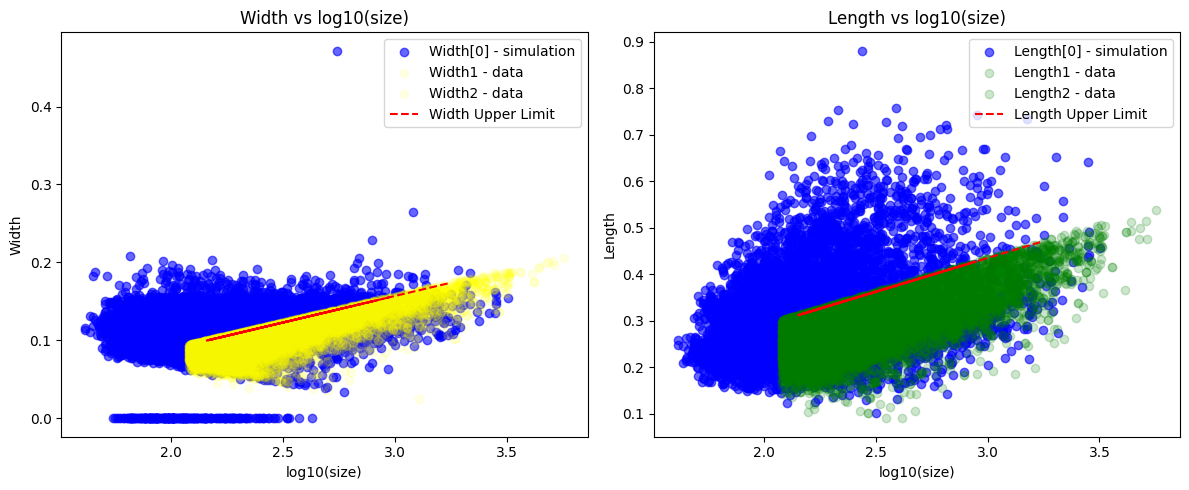

In [34]:
log_size_sim = np.log10(df_simulation_599['size'])

log_size1 = np.log10(source_events['size'])
log_size2 = np.log10(antisource_events['size'])

plt.figure(figsize=(12, 5))

# График для width
plt.subplot(1, 2, 1)
plt.scatter(log_size_sim, df_simulation_599['width[0]'], color='blue', alpha=0.6, label='Width[0] - simulation') # simul
plt.scatter(log_size1, source_events['width'], color='yellow', alpha=0.1, label='Width1 - data')
plt.scatter(log_size2, antisource_events['width'], color='yellow', alpha=0.1, label='Width2 - data')

# Ограничение сверху для width
width_upper_limit = 0.068*log_size - 0.047
plt.plot(log_size, width_upper_limit, color='red', linestyle='--', label='Width Upper Limit')
plt.xlabel('log10(size)')
plt.ylabel('Width')
plt.title('Width vs log10(size)')
plt.legend()

# График для length
plt.subplot(1, 2, 2)
plt.scatter(log_size_sim, df_simulation_599['length[0]'], color='blue', alpha=0.6, label='Length[0] - simulation') # simul
plt.scatter(log_size1, source_events['length'], color='green', alpha=0.2, label='Length1 - data')
plt.scatter(log_size2, antisource_events['length'], color='green', alpha=0.2, label='Length2 - data')

# Ограничение сверху для length
length_upper_limit = 0.145 * log_size
plt.plot(log_size, length_upper_limit, color='red', linestyle='--', label='Length Upper Limit')
plt.xlabel('log10(size)')
plt.ylabel('Length')
plt.title('Length vs log10(size)')
plt.legend()

plt.tight_layout()
plt.show()

### Гистограмма по тета

/tmp/ipykernel_5036/215736496.py:21: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  source_events['disp'] = source_events['ksi'] * (1.0 - source_events['width'] / source_events['length'])
/tmp/ipykernel_5036/215736496.py:22: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  source_events['theta2'] = (source_events['disp']**2 + source_events['dist1']**2 -


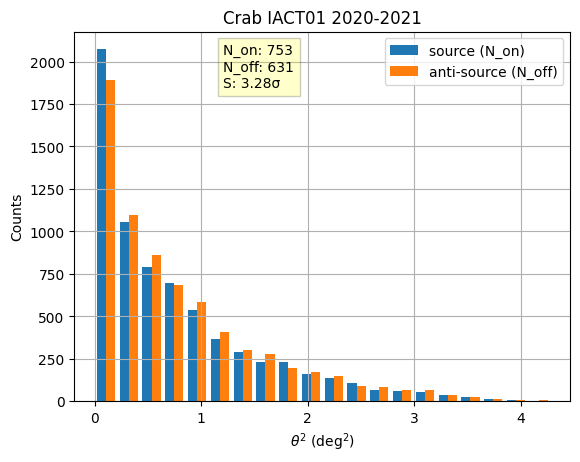

N_on = 753, N_off = 631, Significance = 3.28σ


In [5]:
def calculate_ksi(rc, size):
    if rc < 7.5:
        return 1.3
    elif 7.5 < rc < 10:
        return 1.6
    elif rc > 10:
        if size < 700:
            return 2.0
        elif 700 < size < 1000:
            return 1.9
        elif 1000 < size < 1250:
            return 1.75
        elif 1250 < size < 1500:
            return 1.5
    return np.nan

# Process source events (N_on)
source_events['rc'] = source_events['dist1'] / 0.1206
source_events['ksi'] = source_events.apply(lambda row: calculate_ksi(row['rc'], row['size']), axis=1)
source_events = source_events[~source_events['ksi'].isna()]  # Remove NaN values
source_events['disp'] = source_events['ksi'] * (1.0 - source_events['width'] / source_events['length'])
source_events['theta2'] = (source_events['disp']**2 + source_events['dist1']**2 - 
                          2 * source_events['disp'] * source_events['dist1'] * np.cos(np.radians(source_events['alpha1'])))

# Process anti-source events (N_off)
antisource_events['rc'] = antisource_events['dist2'] / 0.1206
antisource_events['ksi'] = antisource_events.apply(lambda row: calculate_ksi(row['rc'], row['size']), axis=1)
antisource_events = antisource_events[~antisource_events['ksi'].isna()]  # Remove NaN values
antisource_events['disp'] = antisource_events['ksi'] * (1.0 - antisource_events['width'] / antisource_events['length'])
antisource_events['theta2'] = (antisource_events['disp']**2 + antisource_events['dist2']**2 - 
                              2 * antisource_events['disp'] * antisource_events['dist2'] * np.cos(np.radians(antisource_events['alpha2'])))

# Create histogram
plt.hist([source_events['theta2'], antisource_events['theta2']], 
         bins=20, label=['source (N_on)', 'anti-source (N_off)'])
plt.legend(loc='upper right')
plt.xlabel(r'$\theta^2$ (deg$^2$)')
plt.ylabel('Counts')
plt.title('Crab IACT01 2020-2021')

# Calculate statistics (using θ² < 0.05 cut)
theta_cut = 0.05
N_on = len(source_events[source_events['theta2'] < theta_cut])
N_off = len(antisource_events[antisource_events['theta2'] < theta_cut])

# Calculate significance
S = round(np.sqrt(2 * N_on * np.log(2 * (N_on / (N_on + N_off))) + 2 * N_off * np.log(2 * (N_off / (N_on + N_off)))), 2)

plt.annotate(f"N_on: {N_on}\nN_off: {N_off}\nS: {S}σ", 
             fontsize=10, bbox={'facecolor': 'yellow', 'alpha': 0.2},
             xy=(0.3, 0.85), xycoords='axes fraction')

plt.grid()
plt.show()

print(f'N_on = {N_on}, N_off = {N_off}, Significance = {S}σ')

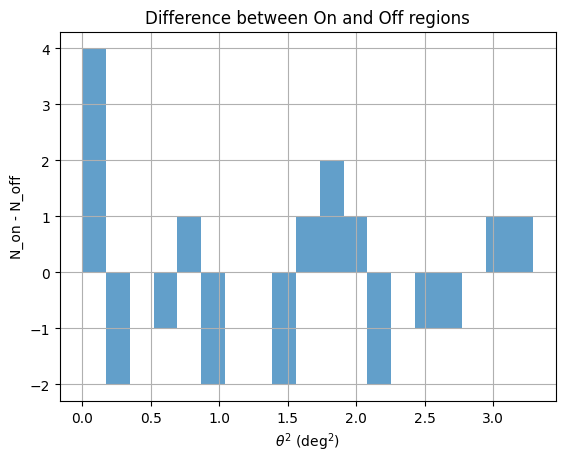

In [49]:
# Вычисляем разницу N_on - N_off для каждого бина θ²
theta_bins = np.linspace(0, max(df['theta2_signal'].max(), df['theta2_background'].max()), 20)
on_hist, _ = np.histogram(df['theta2_signal'], bins=theta_bins)
off_hist, _ = np.histogram(df['theta2_background'], bins=theta_bins)
diff_hist = on_hist - off_hist

# Строим гистограмму разницы
plt.bar(theta_bins[:-1], diff_hist, width=np.diff(theta_bins), align='edge', alpha=0.7)
plt.xlabel(r'$\theta^2$ (deg$^2$)')
plt.ylabel('N_on - N_off')
plt.title('Difference between On and Off regions')
plt.grid(True)
plt.show()

### Гистограмма по alpha

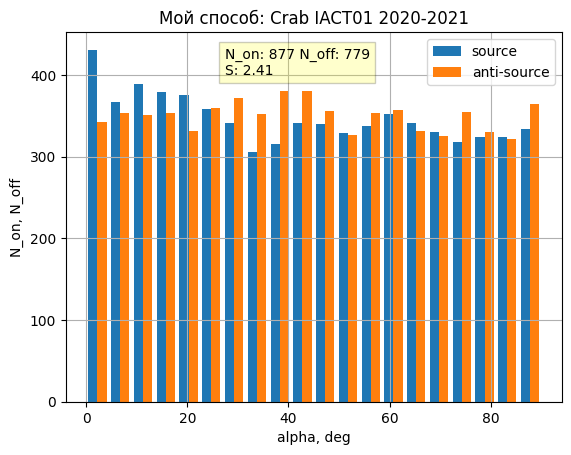

N_on = 877 N_off = 779 S_lima = 2.41


In [12]:
def filter_hillas_data(df):
    common_filters = (
        (df['CR_portion']/np.cos(np.pi/2-np.pi*df['tel_el']/180) > 5) &
        (df['delta_time'] < 0.5) &
        (df['error_deg'] < 0.1) &
        (df['size'] > 120) &
        (df['width'] > 0.024) &
        (df['width'] < 0.068 * np.log10(df['size']) - 0.047) &
        (df['length'] < 0.145 * np.log10(df['size']))
    )
    source_df = df[
        common_filters &
        (df['dist1'].between(0.36, 1.44))
    ].copy()
    source_df['source_type'] = 'source' 
    
    anti_source_df = df[
        common_filters &
        (df['dist2'].between(0.36, 1.44))
    ].copy()
    anti_source_df['source_type'] = 'anti-source'
    return source_df, anti_source_df

source_events, antisource_events = filter_hillas_data(hillas)

plt.hist([source_events['alpha1'],antisource_events['alpha2']], bins=20,
            label=['source', 'anti-source'])#,stacked=True)  
plt.legend(loc='upper right')
plt.xlabel('alpha, deg')
plt.ylabel('N_on, N_off')
plt.title('Мой способ: Crab IACT01 2020-2021') 
N_on = len(source_events.loc[source_events['alpha1']<10])
N_off = len(antisource_events.loc[antisource_events['alpha2']<10])
S = round(np.sqrt(2*N_on*np.log(2*(N_on/(N_on+N_off))) + 2*N_off*np.log(2*(N_off/(N_on+N_off)))),2) #сигма
plt.annotate(f"N_on: {N_on} N_off: {N_off}\nS: {S}", fontsize=10,
            bbox={'facecolor':'yellow','alpha':0.2},
              xy=(3, 21), xytext=(0.32, 0.885), textcoords='axes fraction')
plt.grid()
plt.show()
print('N_on =', N_on, 'N_off =', N_off, 'S_lima =', S)

N_on = 431.0 N_off = 344.0 3.1251322552658833 3.13


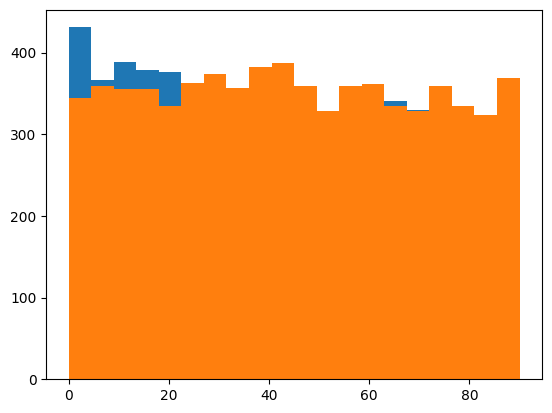

In [13]:
# Пашин В. вариант по альфа
# table_had = pd.read_csv('/media/alexandra/DATA/IACT01_231119/231119.01_out_hillas_14_7.0fix.csv') #23.11.19
table_had = hillas

on10 = plt.hist(table_had['alpha1'][(table_had['CR_portion']/np.cos(np.pi/2-np.pi*table_had['tel_el']/180) > 5) & 
                      (table_had['delta_time'] < 0.5) &
                      (table_had['error_deg'] < 0.1) &
                      (table_had['size'] > 120) & 
                      (table_had['dist1'] > 0.36) & 
                      (table_had['dist1'] < 1.44) & 
                      (table_had['width'] > 0.024) & 
                      (table_had['width'] < (0.068*np.log10(table_had['size'])-0.047)) &
                      (table_had['length'] <0.145*np.log10(table_had['size']))], range=[0,90], bins=20)[0]
off10 = plt.hist(table_had['alpha2'][(table_had['CR_portion']/np.cos(np.pi/2-np.pi*table_had['tel_el']/180) > 5) & 
                      # (table_had['delta_time'] < 0.5) &
                      # (table_had['error_deg'] < 0.1) &
                      (table_had['size'] > 120) & 
                      (table_had['dist2'] > 0.36) & 
                      (table_had['dist2'] < 1.44) & 
                      (table_had['width'] > 0.024) & 
                      (table_had['width'] < (0.068*np.log10(table_had['size'])-0.047)) &
                      (table_had['length'] <0.145*np.log10(table_had['size']))], range=[0,90], bins=20)[0]
N_on = on10[0]
N_off = off10[0]
S_lima = round(np.sqrt(2*N_on*np.log(2*(N_on/(N_on+N_off))) + 2*N_off*np.log(2*(N_off/(N_on+N_off)))),2) #сигма
print('N_on =', on10[0], 'N_off =', off10[0], (on10[0] - off10[0])/np.sqrt(on10[0] + off10[0]), S_lima)

In [13]:
# кат только по дист1? ок или не?
# эффективную площадь построить